In [13]:
"""
Cleaned up version of the integration imports we need to actually run this code together.
"""

import numpy as np
from scipy import signal
from optic.models.devices import mzm, photodiode, edfa, iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel
from optic.models.channels import linearFiberChannel, ssfm
from optic.comm.modulation import modulateGray, grayMapping
from optic.comm.sources import bitSource, symbolSource
from optic.dsp.core import upsample, pulseShape, pnorm, anorm, signalPower, firFilter, decimate, symbolSync,phaseNoise

try:
    from optic.dsp.coreGPU import checkGPU
    if checkGPU():
        from optic.dsp.coreGPU import firFilter
    else:
        from optic.dsp.core import firFilter
except ImportError:
    from optic.dsp.core import firFilter

from optic.utils import parameters, dBm2W, ber2Qfactor
from optic.plot import eyediagram, pconst, plotPSD
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm.notebook import tqdm
import scipy as sp
import scipy.constants as const

try:
    from optic.models.modelsGPU import manakovSSF
except:
    from optic.models.channels import manakovSSF

from optic.dsp.equalization import edc, mimoAdaptEqualizer, ffe
from optic.dsp.carrierRecovery import cpr
from optic.comm.metrics import fastBERcalc, monteCarloGMI, monteCarloMI, calcEVM, bert
from optic.dsp.clockRecovery import gardnerClockRecovery


import logging as logg
logg.basicConfig(level=logg.INFO, format='%(message)s', force=True)
import time

In [3]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Parameters Configuration of Optical System
# ---------------------------------------------------------------------------------------------------------------------------------------


# -----------------------------------------------
# Transmitter Parameters
#-------------------------------------------------

# 1) General Parameters
SpS = 16                 # samples per symbol
Rs = 32e9                # symbol rate [baud]
Fs = Rs * SpS            # sampling frequency [Hz]
M = 16                   # QPSK -> M=4, constType='qam'
nBits = 400000           # total bits to generate
rollOff = 0.01           # RRC roll-off
nFilterTaps = 1024       # RRC filter taps
mzmScale = 0.5           # IQM drive scale = "modulation depth" (0.5 is default in OptiCommPy)
Vpi = 2                  # IQM pi Voltage  (2V is defualt in OpticommPy)
P_launch_dBm = 0         # desired launched optical power [dBm] -- for 4QAM try 6 dbm -- for 16QAM 0 was good
laserLinewidth = 0   # Hz (set e.g. 100e3 for phase noise), setting laserLineWidth to 0, models the ideal case 

# 2) Symbol Source Parameters
paramSymb = parameters()
paramSymb.nSymbols = int(nBits // np.log2(M))  # symbols = bits / log2(M)
paramSymb.M = M
paramSymb.constType = "qam"                    # 'qam' with M=4 -> QPSK
paramSymb.dist = "uniform"                     # uniform symbol probabilities
paramSymb.seed = 444
paramSymb.shapingFactor = 0

constSymb = grayMapping(paramSymb.M, paramSymb.constType)
if paramSymb.dist == "uniform":
   px = np.ones(paramSymb.M) / paramSymb.M
elif paramSymb.probDist == "maxwell-boltzmann":
   px = np.exp(-paramSymb.shapingFactor * np.abs(constSymb) ** 2)
   px = px / np.sum(px)
else:
   raise ValueError("Invalid probability distribution.")
paramSymb.px = px

# 3) UpSampling and FIR Parameters
paramPulse = parameters()
paramPulse.pulseType = "rrc"
paramPulse.nFilterTaps = nFilterTaps
paramPulse.rollOff = rollOff
paramPulse.SpS = SpS

# 4) IQM Parameters
paramIQM = parameters()
paramIQM.Vpi = Vpi
paramIQM.VbI = -Vpi
paramIQM.VbQ = -Vpi
paramIQM.Vphi = Vpi/2


# -----------------------------------------------
# Receiver Parameters
#------------------------------------------------

# 1) Local oscillator (LO) parameters:
FO  = 0                 # frequency offset
paramLO = parameters()
paramLO.P =2              # power in dBm
paramLO.lw = 0          # laser linewidth
paramLO.RIN_var = 0
paramLO.Fs = Fs
paramLO.seed = 789 # random seed for noise generation
paramLO.freqShift = 0  

# 2) Photodiodes parameters
paramPD = parameters()
paramPD.B = Rs
paramPD.Fs = Fs
paramPD.ideal = True
paramPD.seed = 1011
paramPD.R = 1
paramPD.shotNoise = False
paramPD.thermalNoise = False
paramPD.currentSaturation = False
paramPD.bandwidthLimitation = False

# 3) Frontend parameters
paramFE = parameters()
paramFE.Fs = Fs
paramFE.phaseImb = 0
paramFE.ampImb = 0
paramFE.timeSkew = 0



In [5]:
def simulate_phase_noise():

    # Tx 
    symbTx = symbolSource(paramSymb)      
    
    pulse = pulseShape(paramPulse)
    symbolsUp = upsample(symbTx, SpS)
    sigTx = firFilter(pulse, symbolsUp)

    # 5) Optical Carrier / LO field (Ein)
    sigTx_length = paramSymb.nSymbols * SpS

    sigTx = sigTx / np.max(np.abs(sigTx))

    # Keep the Tx laser ideal
    sigLO = np.ones_like(sigTx)

    # Iqm
    sigTxo = iqm(sigLO, mzmScale * sigTx, paramIQM)

    # -------------------------
    # 5) Set launched optical power
    # -------------------------
    # pnorm() normalizes the optical field so that mean(|E|^2)=1.
    # Then multiplying by sqrt(P) sets mean optical power to P (watts).
    # P_launch_W = dBm2W(P_launch_dBm)
    # sigTxo = np.sqrt(P_launch_W) * pnorm(sigTxo)
    # Does not affect phase noise behaviour, can be kept in or removed

    # No Channel
    sigCh = sigTxo

    # Rx LO with phase noise
    paramLO.Ns = len(sigCh)

    sigLO_Rx = basicLaserModel(paramLO)

    # Coherent receiver
    sigRx = coherentReceiver(sigCh, sigLO_Rx, paramFE, paramPD)

    return sigRx, sigLO_Rx, paramLO.Ns

<Figure size 1000x800 with 0 Axes>

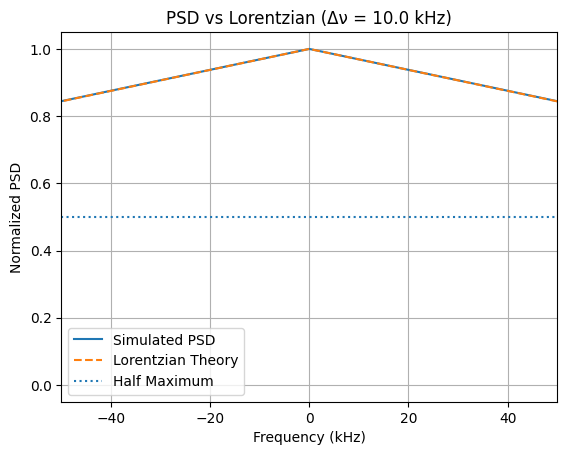

Peak frequency: 0.0


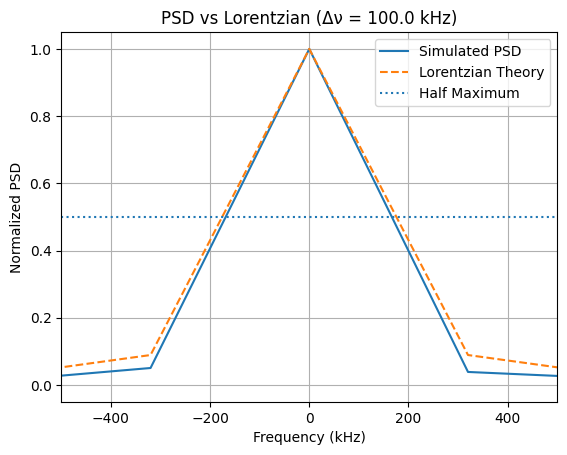

Peak frequency: 0.0


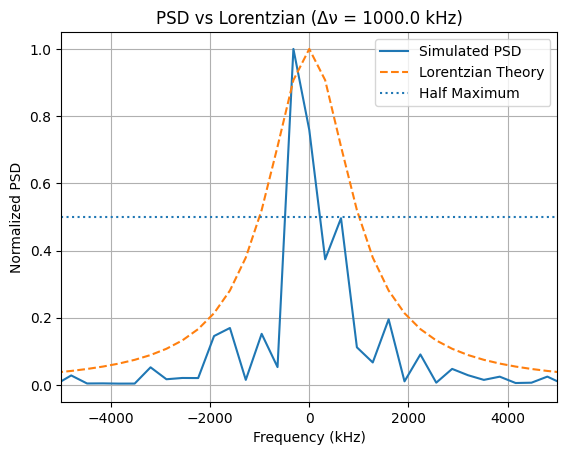

Peak frequency: -320000.0


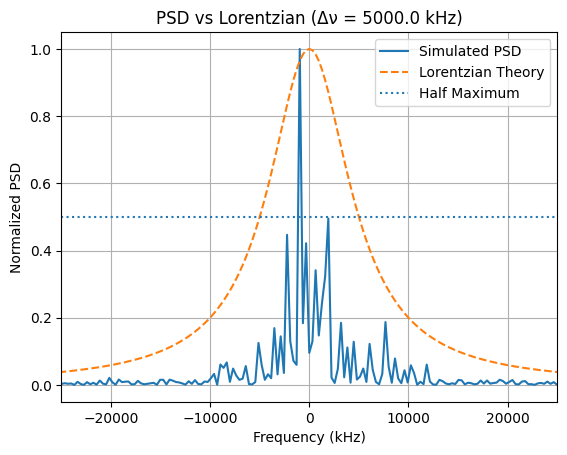

Peak frequency: -960000.0


In [11]:
import numpy as np
import matplotlib.pyplot as plt

sigRx, sigLO_Rx, paramLO.Ns = simulate_phase_noise()


def compare_psd_with_lorentz(sig, Fs, laserLinewidth):

    N = len(sig)
    Ts = 1/Fs

    # FFT-based PSD
    S = np.fft.fftshift(np.fft.fft(sig) / N)
    PSD_sim = np.abs(S)**2 / Ts

    f = np.fft.fftshift(np.fft.fftfreq(N, Ts))

    # Normalize for shape comparison
    PSD_sim /= np.max(PSD_sim)

    # Lorentzian in Hz (not rad/s)
    delta_nu = laserLinewidth
    tc = 1 / (np.pi * delta_nu)

    PSD_theory = (tc) / (1 + (np.pi * (f - 0) * tc)**2)
    PSD_theory /= np.max(PSD_theory)

    # Plot
    plt.figure()
    plt.plot(f/1e3, PSD_sim, label="Simulated PSD")
    plt.plot(f/1e3, PSD_theory, '--', label="Lorentzian Theory")

    plt.axhline(0.5, linestyle=':', label="Half Maximum")

    plt.xlim(-5*delta_nu/1e3, 5*delta_nu/1e3)
    plt.xlabel("Frequency (kHz)")
    plt.ylabel("Normalized PSD")
    plt.title(f"PSD vs Lorentzian (Δν = {delta_nu/1e3} kHz)")
    plt.grid()
    plt.legend()
    plt.show()

    print("Peak frequency:", f[np.argmax(PSD_sim)])

linewidths = [ 10e3, 100e3, 1e6, 5e6]

plt.figure(figsize=(10, 8))

for i, lw in enumerate(linewidths):
    paramLO.lw = lw
    sigRx, sigLO_Rx, paramLO.Ns = simulate_phase_noise()

    compare_psd_with_lorentz(sigLO_Rx, Fs, lw)

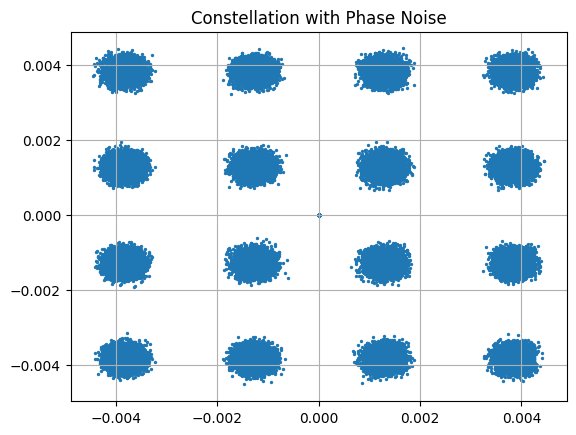

In [43]:
# Constellation Plot
paramLO.lw = 0
sigRx, sigLO_Rx, paramLO.Ns = simulate_phase_noise()

plt.scatter(sigRx.real[::SpS], sigRx.imag[::SpS], s=2)
plt.title("Constellation with Phase Noise")
plt.grid()

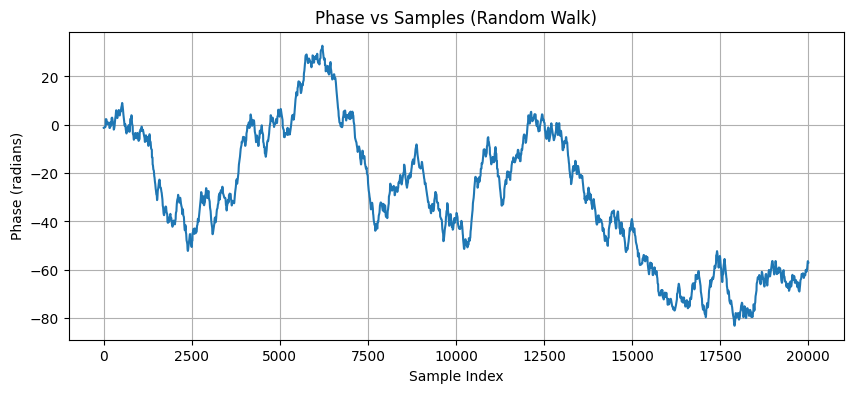

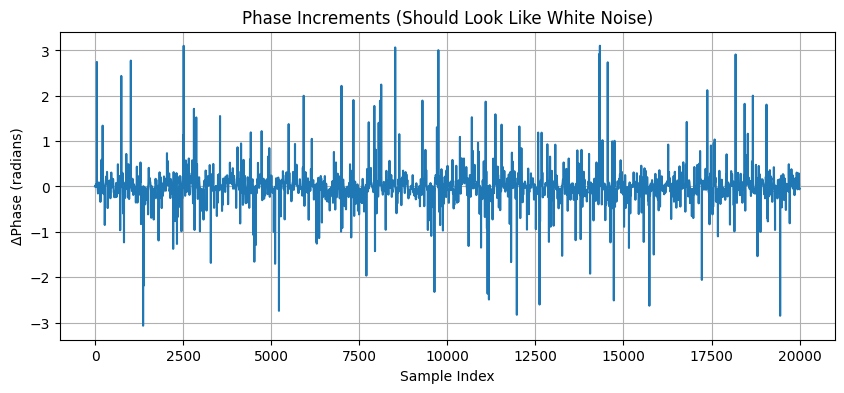

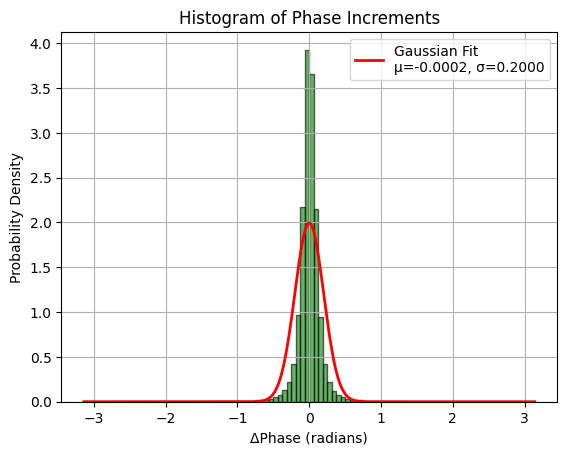

Mean increment: -0.000249, Std dev: 0.199966


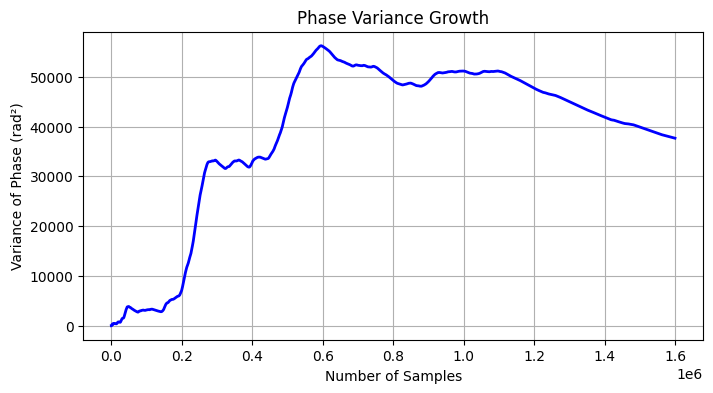

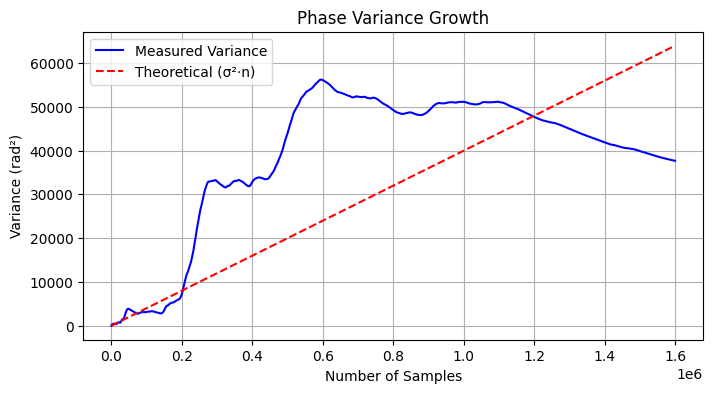

In [44]:
from scipy.stats import norm, shapiro, kstest
paramLO.lw = 100e3
sigRx, sigLO_Rx, paramLO.Ns = simulate_phase_noise()
phase = np.unwrap(np.angle(sigRx))

# --- 1. Plot the random walk (phase) ---
plt.figure(figsize=(10, 4))
plt.plot(phase[:20000])
plt.title("Phase vs Samples (Random Walk)")
plt.xlabel("Sample Index")
plt.ylabel("Phase (radians)")
plt.grid(True)
plt.show()

# --- 2. Plot the phase increments ---
dphi = np.diff(phase)

plt.figure(figsize=(10, 4))
plt.plot(dphi[:20000])
plt.title("Phase Increments (Should Look Like White Noise)")
plt.xlabel("Sample Index")
plt.ylabel("ΔPhase (radians)")
plt.grid(True)
plt.show()

# --- 3. Histogram of increments + Gaussian fit ---
mu, sigma = norm.fit(dphi)
count, bins, _ = plt.hist(dphi, bins=100, density=True, alpha=0.6, color='g', edgecolor='black')

x = np.linspace(min(dphi), max(dphi), 500)
pdf = norm.pdf(x, mu, sigma)
plt.plot(x, pdf, 'r-', linewidth=2, label=f'Gaussian Fit\nμ={mu:.4f}, σ={sigma:.4f}')

plt.title("Histogram of Phase Increments")
plt.xlabel("ΔPhase (radians)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

print(f"Mean increment: {mu:.6f}, Std dev: {sigma:.6f}")

# Compute variance over increasing sample windows
window_sizes = np.arange(10, len(phase), step=500)  # step controls resolution
variances = [np.var(phase[:w]) for w in window_sizes]

# Plot variance vs. sample index
plt.figure(figsize=(8, 4))
plt.plot(window_sizes, variances, 'b-', linewidth=2)
plt.title("Phase Variance Growth")
plt.xlabel("Number of Samples")
plt.ylabel("Variance of Phase (rad²)")
plt.grid(True)
plt.show()

# Stats
mu = np.mean(dphi)
sigma = np.std(dphi)

# Measured variance growth
window_sizes = np.arange(10, len(phase), step=500)
measured_var = [np.var(phase[:w]) for w in window_sizes]

# Theoretical variance growth for a Wiener process
theoretical_var = sigma**2 * window_sizes

# Plot
plt.figure(figsize=(8, 4))
plt.plot(window_sizes, measured_var, 'b-', label="Measured Variance")
plt.plot(window_sizes, theoretical_var, 'r--', label="Theoretical (σ²·n)")
plt.title("Phase Variance Growth")
plt.xlabel("Number of Samples")
plt.ylabel("Variance (rad²)")
plt.legend()
plt.grid(True)
plt.show()



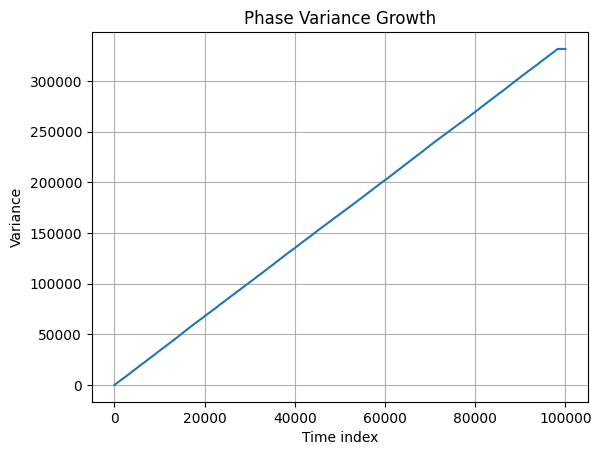

In [45]:
phase = np.unwrap(np.angle(sigRx[::SpS]))  # symbol-rate samples

dphi = np.diff(phase)

var_growth = np.cumsum(dphi**2)

plt.plot(var_growth)
plt.title("Phase Variance Growth")
plt.xlabel("Time index")
plt.ylabel("Variance")
plt.grid()

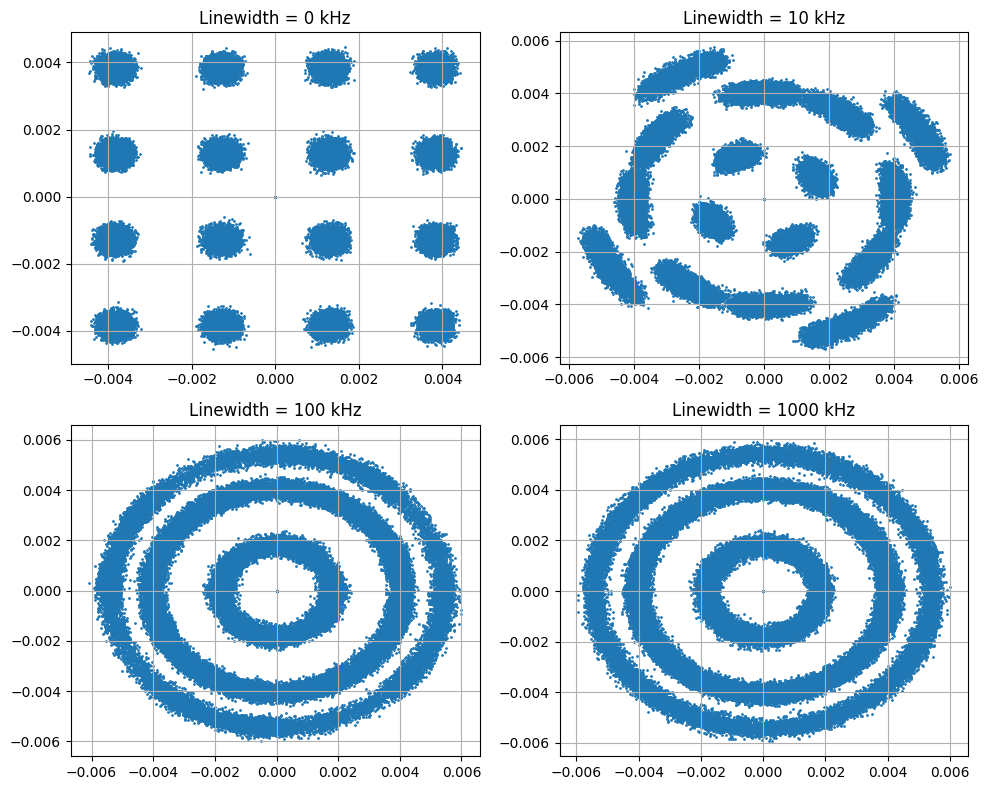

In [46]:
linewidths = [0, 10e3, 100e3, 1e6]

plt.figure(figsize=(10, 8))

for i, lw in enumerate(linewidths):
    paramLO.lw = lw
    sigRx, sigLO_Rx, paramLO.Ns = simulate_phase_noise()

    plt.subplot(2, 2, i+1)
    plt.scatter(sigRx.real[::SpS], sigRx.imag[::SpS], s=1)
    plt.title(f"Linewidth = {lw/1e3:.0f} kHz")
    plt.grid()

plt.tight_layout()

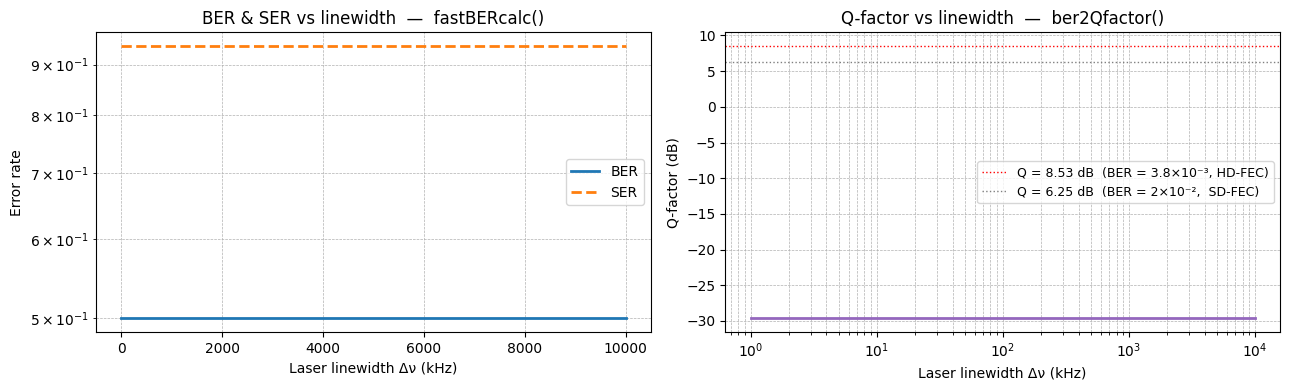

TypeError: only 0-dimensional arrays can be converted to Python scalars

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, probplot

from optic.comm.metrics import fastBERcalc, monteCarloGMI, monteCarloMI, calcEVM
from optic.comm.modulation import grayMapping
from optic.dsp.core import pnorm, phaseNoise
from optic.utils import ber2Qfactor

linewidths = [0, 10e3, 100e3, 1e6]
lw_labels  = [f"{lw/1e3:.0f} kHz" for lw in linewidths]
colors_lw  = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

Ts = 1 / Fs
N_samples = paramSymb.nSymbols * SpS


# ── Helper ───────────────────────────────────────────────────────────────────
def get_symbols(lw):
    """Return (symbTx, symbRx) at symbol rate — both pnorm'd."""
    paramLO.lw = lw
    sigRx, _, _ = simulate_phase_noise()
    symbTx = symbolSource(paramSymb)
    symbRx = pnorm(sigRx[::SpS])
    return symbTx, symbRx


# ── 1. Q-Q plot of phase increments vs Gaussian ──────────────────────────────
# phaseNoise() gives the clean Wiener sequence; probplot() is the rigorous
# normality test — more reliable than a histogram at the tails.
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, lw, lab, col in zip(axes.flat, linewidths, lw_labels, colors_lw):
    phi  = phaseNoise(lw if lw > 0 else 1e2, N_samples, Ts)  # avoid lw=0 edge case
    dphi = np.diff(phi)

    (osm, osr), (slope, intercept, r) = probplot(dphi, dist='norm')
    ax.scatter(osm, osr, s=1, color=col, alpha=0.5, label=f"R²={r**2:.5f}")
    ax.plot(osm, slope * np.array(osm) + intercept,
            'k--', linewidth=1, label="Ideal Gaussian")

    ax.set_title(f"Δν = {lab}")
    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel("Sample quantiles (rad)")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', linewidth=0.5)

fig.suptitle("Q-Q plot of phase increments vs Gaussian  —  phaseNoise()\n"
             "R² close to 1.0 confirms pure Wiener process", fontsize=11)
plt.tight_layout()
plt.show()


# ── 2. Phase variance vs time — all linewidths overlaid ──────────────────────
# Uses phaseNoise() directly; overlays σ²·n theoretical line per linewidth.
# This replaces the per-subplot version from the earlier notebook.
fig, ax = plt.subplots(figsize=(9, 4))

for lw, lab, col in zip(linewidths, lw_labels, colors_lw):
    lw_run = lw if lw > 0 else 1e2
    phi    = phaseNoise(lw_run, N_samples, Ts)
    dphi   = np.diff(phi)
    sigma2 = np.var(dphi)

    stride   = 200
    n        = np.arange(1, len(phi))
    measured = [np.var(phi[:k]) for k in n[::stride]]
    theory   = sigma2 * n[::stride]
    t_us     = n[::stride] / Fs * 1e6

    ax.plot(t_us, measured, color=col, linewidth=1.8, label=f"Δν = {lab}")
    ax.plot(t_us, theory,   color=col, linewidth=1,   linestyle='--', alpha=0.5)

ax.set_xlabel("Time (µs)")
ax.set_ylabel("Phase variance (rad²)")
ax.set_title("Phase variance growth — all linewidths overlaid\n"
             "solid = measured, dashed = theoretical σ²·n  —  phaseNoise()")
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

